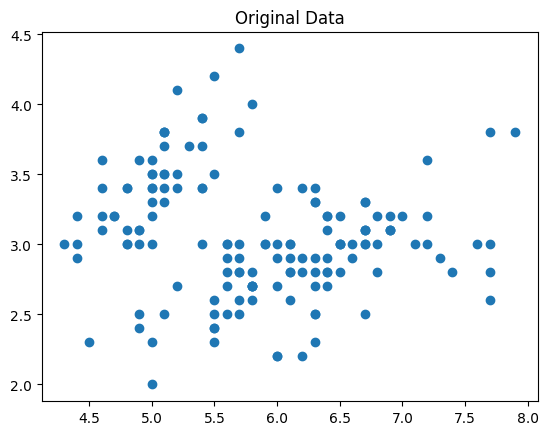

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X = data.data[:, :2]   # take only 2 features for easy visualization

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.show()

In [12]:
class KMeansScratch:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters

    def fit(self, X):
        np.random.seed(42)
        self.centroids = X[np.random.choice(len(X), self.k, replace=False)]

        for _ in range(self.max_iters):
            # Assign clusters
            self.labels = self._assign_clusters(X)

            # Compute new centroids
            new_centroids = np.array([
                X[self.labels == i].mean(axis=0) for i in range(self.k)
            ])

            # Stop if no change
            if np.all(self.centroids == new_centroids):
                break

            self.centroids = new_centroids

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

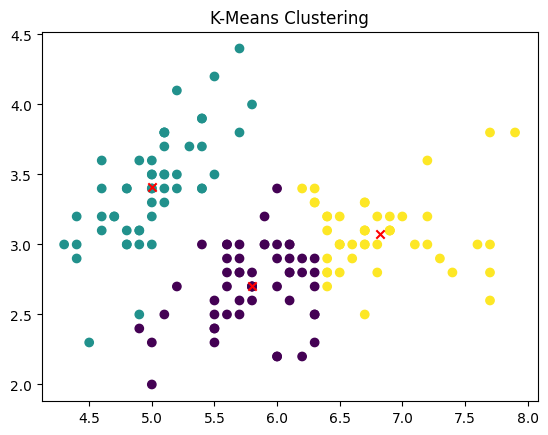

In [13]:
kmeans = KMeansScratch(k=3)
kmeans.fit(X)

plt.scatter(X[:,0], X[:,1], c=kmeans.labels)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], c='red', marker='x')
plt.title("K-Means Clustering")
plt.show()

In [14]:
class HierarchicalScratch:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters

    def fit(self, X):
        self.X = X
        clusters = [[i] for i in range(len(X))]

        while len(clusters) > self.n_clusters:
            min_dist = float('inf')
            to_merge = (0, 1)

            for i in range(len(clusters)):
                for j in range(i+1, len(clusters)):
                    dist = self._cluster_distance(clusters[i], clusters[j])
                    if dist < min_dist:
                        min_dist = dist
                        to_merge = (i, j)

            # Merge clusters
            i, j = to_merge
            clusters[i] += clusters[j]
            clusters.pop(j)

        # Assign labels
        self.labels = np.zeros(len(X))
        for idx, cluster in enumerate(clusters):
            for point in cluster:
                self.labels[point] = idx

    def _cluster_distance(self, c1, c2):
        return min(
            np.linalg.norm(self.X[i] - self.X[j])
            for i in c1 for j in c2
        )

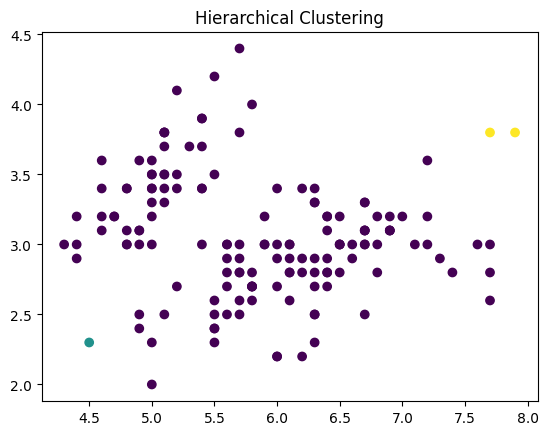

In [15]:
hc = HierarchicalScratch(n_clusters=3)
hc.fit(X)

plt.scatter(X[:,0], X[:,1], c=hc.labels)
plt.title("Hierarchical Clustering")
plt.show()

In [16]:
class DBSCANScratch:
    def __init__(self, eps=0.5, min_pts=5):
        self.eps = eps
        self.min_pts = min_pts

    def fit(self, X):
        self.X = X
        self.labels = [-1] * len(X)
        cluster_id = 0

        for i in range(len(X)):
            if self.labels[i] != -1:
                continue

            neighbors = self._region_query(i)

            if len(neighbors) < self.min_pts:
                self.labels[i] = -1  # noise
            else:
                self._expand_cluster(i, neighbors, cluster_id)
                cluster_id += 1

    def _region_query(self, idx):
        return [
            i for i in range(len(self.X))
            if np.linalg.norm(self.X[idx] - self.X[i]) <= self.eps
        ]

    def _expand_cluster(self, idx, neighbors, cluster_id):
        self.labels[idx] = cluster_id
        i = 0

        while i < len(neighbors):
            point = neighbors[i]

            if self.labels[point] == -1:
                self.labels[point] = cluster_id

            elif self.labels[point] == -1:
                self.labels[point] = cluster_id
                new_neighbors = self._region_query(point)

                if len(new_neighbors) >= self.min_pts:
                    neighbors += new_neighbors

            i += 1

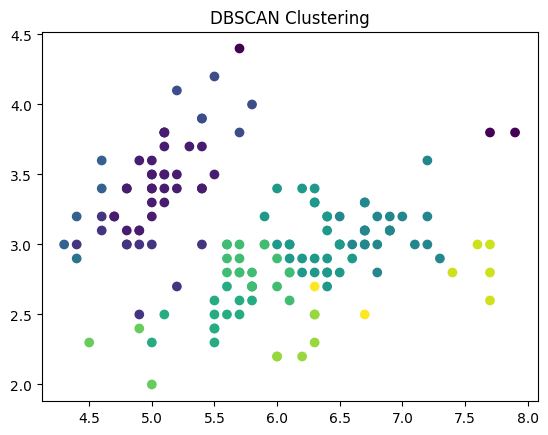

In [17]:
db = DBSCANScratch(eps=0.5, min_pts=5)
db.fit(X)

plt.scatter(X[:,0], X[:,1], c=db.labels)
plt.title("DBSCAN Clustering")
plt.show()

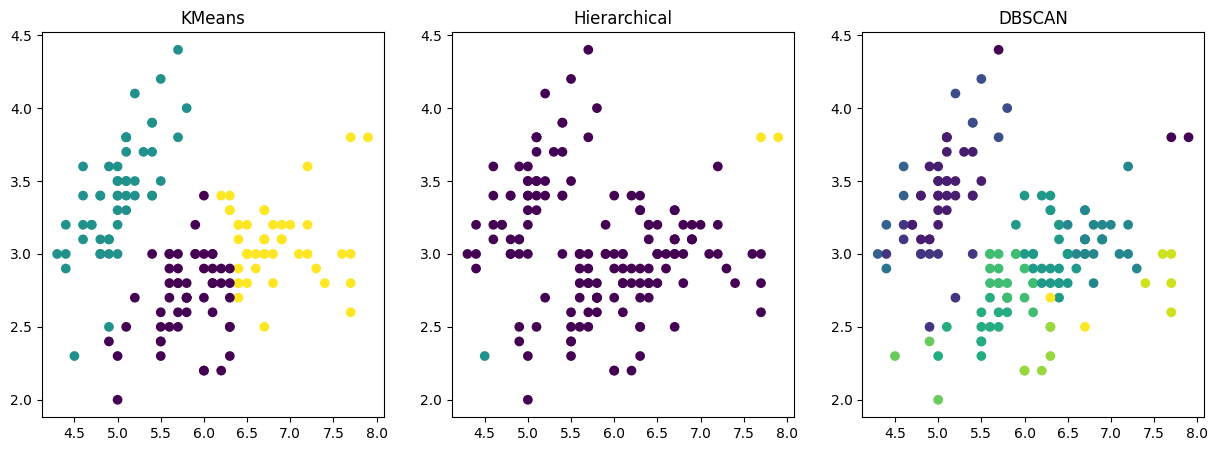

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].scatter(X[:,0], X[:,1], c=kmeans.labels)
axs[0].set_title("KMeans")

axs[1].scatter(X[:,0], X[:,1], c=hc.labels)
axs[1].set_title("Hierarchical")

axs[2].scatter(X[:,0], X[:,1], c=db.labels)
axs[2].set_title("DBSCAN")

plt.show()